<a href="https://colab.research.google.com/github/KiselevaStacy/python-ai--/blob/main/notebooks/week3_dogs_3d_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐕 Week 3: Обобщённый график — масса, рост и продолжительность жизни

## Цель: Визуализировать три параметра пород собак на одном графике

**Параметры:**
- X = масса (кг)
- Y = высота в холке (см)
- Цвет / размер / толщина = продолжительность жизни (лет)

**Задача:** Выбрать наиболее наглядный способ кодировки третьей переменной.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy import stats

repo_path = "/content/python-ai--"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/KiselevaStacy/python-ai--.git
if os.getcwd() != repo_path:
    %cd python-ai--

print("✅ Репозиторий готов\n")

df_dogs = pd.read_csv("data/dog_breeds.csv")
print(f"📊 Загружено строк в df_dogs: {len(df_dogs)}")

if "dogBreed" in df_dogs.columns:
    df_dogs = df_dogs.rename(columns={"dogBreed": "URL"})

technical_cols = ["heightQualifierLabel", "massQualifierLabel", "lifeExpectancyQualifierLabel",
                  "heightUnit", "massUnit", "lifeExpectancyUnit"]
cols_to_drop = [c for c in technical_cols if c in df_dogs.columns]
if cols_to_drop:
    df_dogs = df_dogs.drop(columns=cols_to_drop)

breed_col = None
for col in ["dogBreedLabel", "breedLabel", "Breed", "breed", "name", "label"]:
    if col in df_dogs.columns:
        breed_col = col
        break
if breed_col:
    df_dogs = df_dogs.rename(columns={breed_col: "dogBreed"})

for col in ["height", "mass", "lifeExpectancy"]:
    if col in df_dogs.columns:
        df_dogs[col] = pd.to_numeric(df_dogs[col], errors="coerce")

print("✅ df_dogs очищен\n")

# Группировка по породам
df_ranges = df_dogs.groupby('dogBreed').agg(
    mass_min=('mass', 'min'),
    mass_max=('mass', 'max'),
    height_min=('height', 'min'),
    height_max=('height', 'max'),
    lifeExpectancy=('lifeExpectancy', 'median')
).reset_index()

# Фильтруем породы с полными данными по всем трём параметрам
df_combined = df_ranges[
    df_ranges['mass_min'].notna() &
    df_ranges['mass_max'].notna() &
    df_ranges['height_min'].notna() &
    df_ranges['height_max'].notna() &
    df_ranges['lifeExpectancy'].notna()
].copy()

print(f"✅ Пород с полными данными по трём параметрам: {len(df_combined)}")

# Перевод названий на русский
BREED_TRANSLATIONS = {
    "Ariege Pointer":       "Арьежский пуантёр",
    "Cesky Fousek":         "Чешский фоусек",
    "Chippiparai":          "Чиппипарай",
    "Mudhol Hound":         "Мудхольская борзая",
    "Pembroke Welsh Corgi": "Вельш-корги пемброк",
}
df_combined["dogBreed_ru"] = df_combined["dogBreed"].replace(BREED_TRANSLATIONS)

print(df_combined[['dogBreed_ru', 'mass_min', 'mass_max', 'height_min', 'height_max', 'lifeExpectancy']].head(10))

/content/python-ai--
✅ Репозиторий готов

📊 Загружено строк в df_dogs: 2434
✅ df_dogs очищен

✅ Пород с полными данными по трём параметрам: 16
                       dogBreed_ru  mass_min  mass_max  height_min  \
38                  Чешский фоусек      22.0      34.0        58.0   
127            Вельш-корги пемброк       9.0      12.0        25.0   
218            Аляскинский маламут      34.0      38.0        58.5   
221  Американский водяной спаниель      11.5      20.5        38.0   
224         Американский фоксхаунд      30.0      34.0        53.0   
226           Анатолийская овчарка      40.0      65.0        71.0   
239               Афганская борзая      23.0      27.0        63.0   
240                    Аффенпинчер       4.0       6.0        25.0   
245                   Бассет-хаунд      32.0      32.0        33.0   
384               Немецкая овчарка      22.0      40.0        55.0   

     height_max  lifeExpectancy  
38         66.0            12.0  
127        30.0   

# 💬 Фидбек AI 1 (к подготовке данных)

**Результат:** Получено 16 пород с полными данными по массе, росту и продолжительности жизни.

**Требование преподавателя:** Построить обобщённый график, где третья переменная (продолжительность жизни) закодирована визуально.

**Варианты кодировки:**
1. Цвет заливки прямоугольника
2. Толщина рамки
3. Вложенные рамки (количество обводок)
4. Размер точки в центре
5. Насыщенность / прозрачность цвета

## 📊 Вариант A: Цвет заливки прямоугольника (рекомендованный)

**Логика:** Красный = меньше лет, зелёный = больше лет. Интуитивно понятно, не требует дополнительных пояснений.

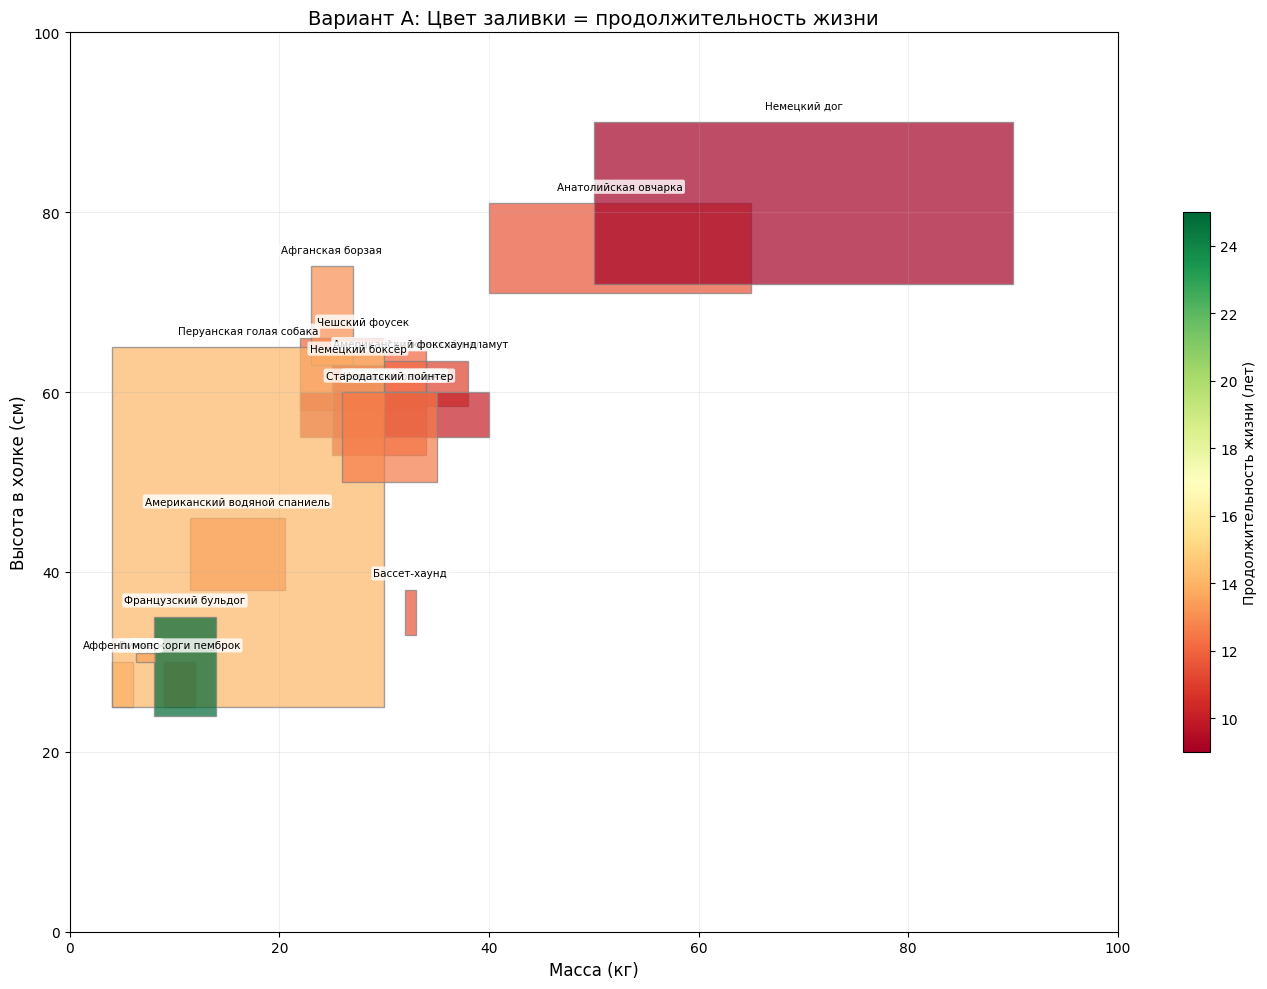

In [2]:
fig, ax = plt.subplots(figsize=(14, 10))

life_min = df_combined['lifeExpectancy'].min()
life_max = df_combined['lifeExpectancy'].max()
norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    color = cmap(norm(row['lifeExpectancy']))

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=True, facecolor=color, edgecolor='gray',
        alpha=0.7, linewidth=1
    )
    ax.add_patch(rect)

    # Подпись
    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант А: Цвет заливки = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 📊 Вариант B: Толщина рамки

**Логика:** Чем толще рамка, тем дольше живёт собака. Тонкая/прозрачная рамка — недолго живёт.

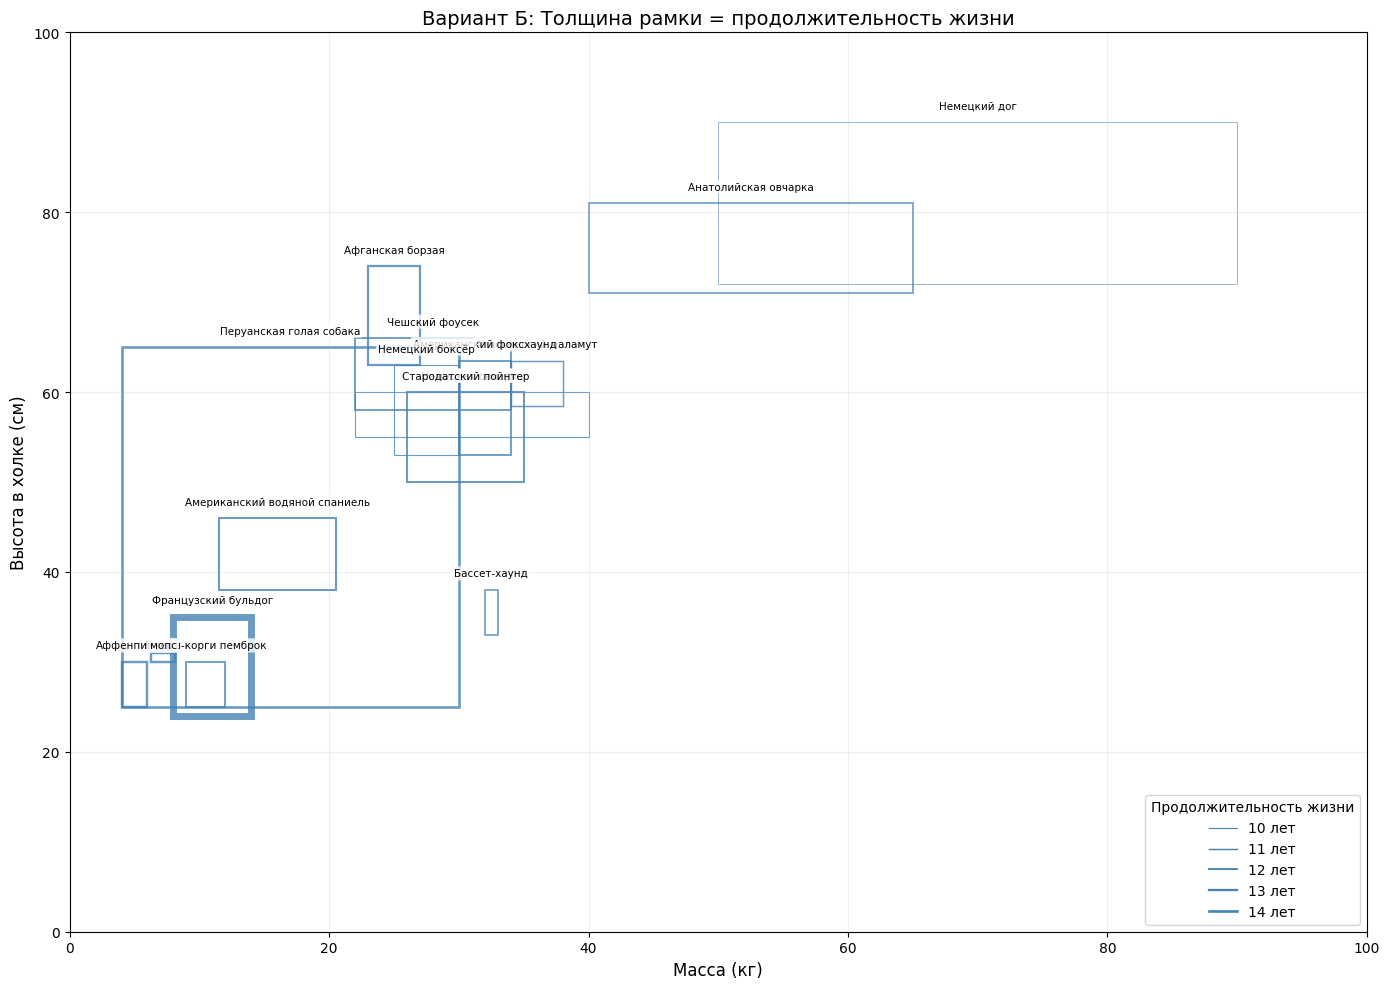

In [3]:
fig, ax = plt.subplots(figsize=(14, 10))

lw_min, lw_max = 0.5, 5.0
life_range = life_max - life_min

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']

    lw = lw_min + (row['lifeExpectancy'] - life_min) / life_range * (lw_max - lw_min)

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=False, edgecolor='steelblue', linewidth=lw, alpha=0.8
    )
    ax.add_patch(rect)

    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

# Легенда для толщины линии
legend_elements = []
for life in [10, 11, 12, 13, 14]:
    lw = lw_min + (life - life_min) / life_range * (lw_max - lw_min)
    legend_elements.append(plt.Line2D([0], [0], color='steelblue', linewidth=lw, label=f'{life} лет'))
ax.legend(handles=legend_elements, loc='lower right', title='Продолжительность жизни')

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант Б: Толщина рамки = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 📊 Вариант C: Вложенные рамки (количество обводок)

**Логика:** Чем больше обводок вокруг прямоугольника, тем дольше живёт собака. Каждая обводка = +1 год или +0.5 года.

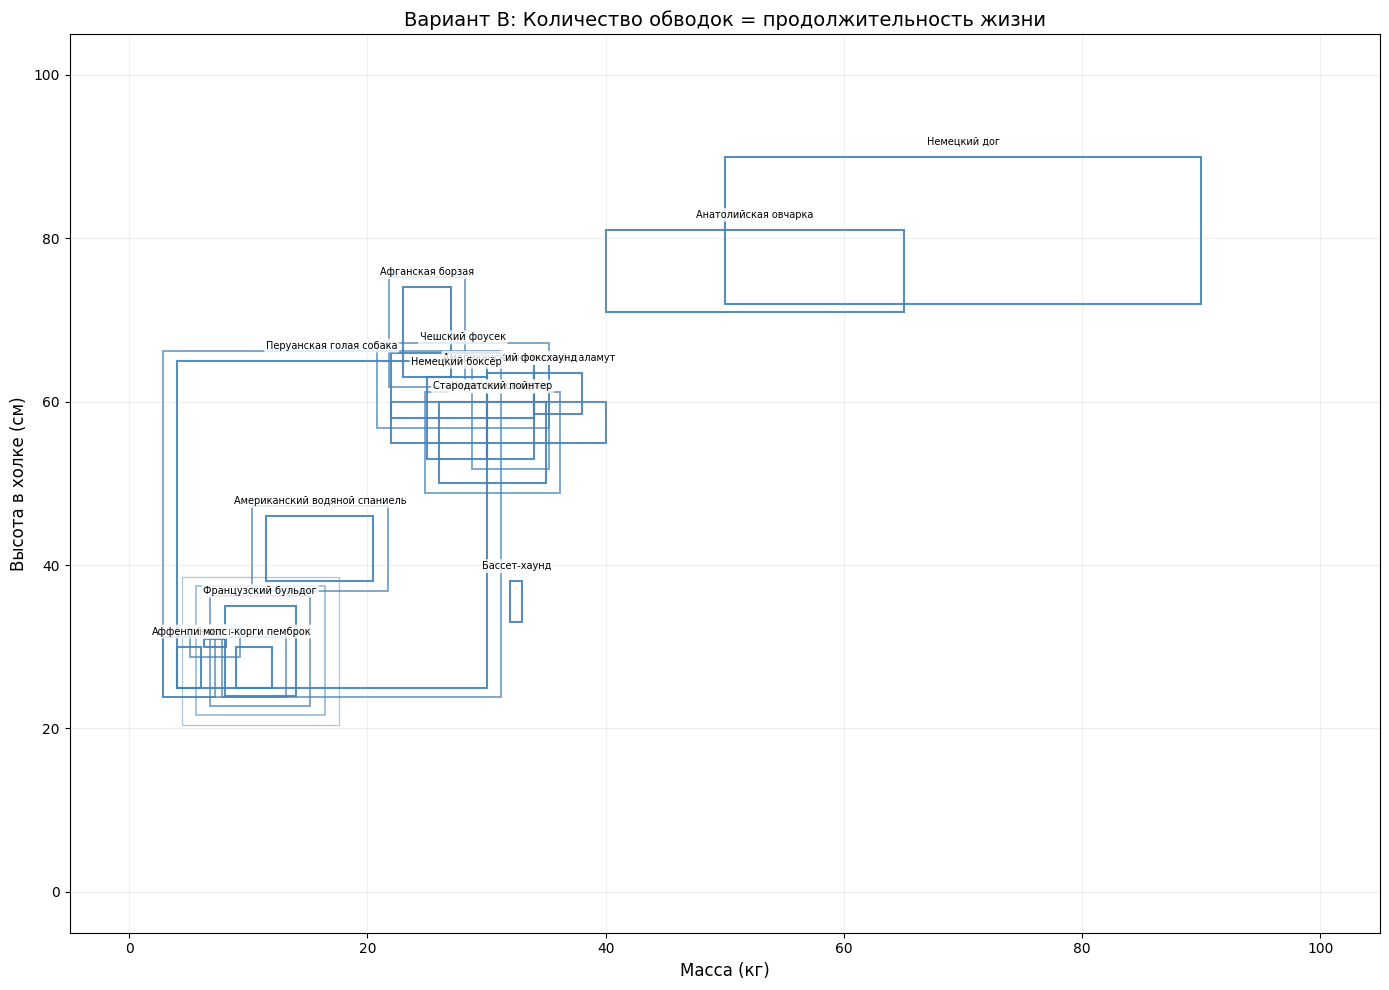

In [4]:
fig, ax = plt.subplots(figsize=(14, 10))

MAX_RINGS = 4
life_range = life_max - life_min

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']

    n = max(1, round(1 + (row['lifeExpectancy'] - life_min) / life_range * (MAX_RINGS - 1)))
    step = 1.2

    for r in range(n):
        pad = r * step
        rect = plt.Rectangle(
            (row['mass_min'] - pad, row['height_min'] - pad),
            max(mass_w, 1) + 2 * pad,
            max(height_h, 1) + 2 * pad,
            fill=False, edgecolor='steelblue',
            linewidth=1.5 - r * 0.2, alpha=0.9 - r * 0.15
        )
        ax.add_patch(rect)

    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант В: Количество обводок = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

## 📊 Вариант D: Размер точки в центре

**Логика:** Чем больше точка в центре прямоугольника, тем дольше живёт собака. Нейтральный и читаемый вариант.

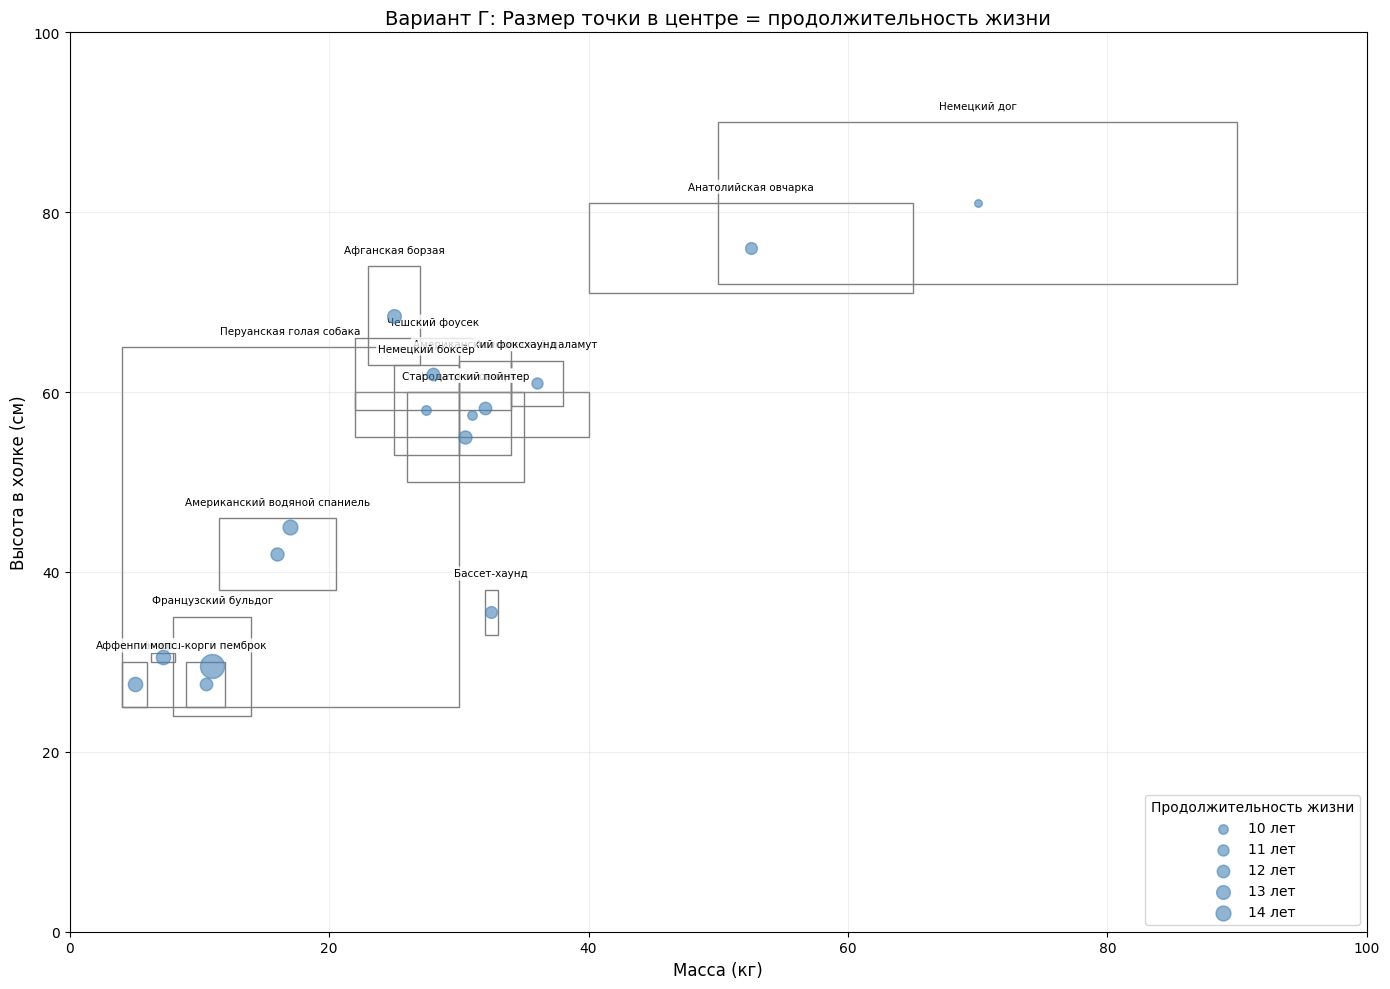

In [5]:
fig, ax = plt.subplots(figsize=(14, 10))

size_min, size_max = 30, 300

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']

    # Прямоугольник (контур)
    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=False, edgecolor='gray', linewidth=1
    )
    ax.add_patch(rect)

    # Точка в центре (размер пропорционален жизни)
    center_x = row['mass_min'] + max(mass_w, 1) / 2
    center_y = row['height_min'] + max(height_h, 1) / 2
    size = size_min + (row['lifeExpectancy'] - life_min) / life_range * (size_max - size_min)

    ax.scatter(center_x, center_y, s=size, color='steelblue', alpha=0.6, zorder=5)

    # Подпись
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

# Легенда для размера точек
legend_sizes = []
for life in [10, 11, 12, 13, 14]:
    size = size_min + (life - life_min) / life_range * (size_max - size_min)
    legend_sizes.append(plt.scatter([], [], s=size, c='steelblue', alpha=0.6, label=f'{life} лет'))
ax.legend(handles=legend_sizes, loc='lower right', title='Продолжительность жизни')

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Вариант Г: Размер точки в центре = продолжительность жизни', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# 💬 Фидбек AI 2 (выбор варианта кодировки)

**Сравнение четырёх вариантов:**

| Вариант | Достоинства | Недостатки | Оценка |
|---------|-------------|------------|--------|
| **А: Цвет** | Интуитивный, легко читается, не перегружает график | Требует цветовой шкалы | ⭐⭐⭐⭐⭐ |
| **Б: Толщина рамки** | Монохромный, хорошо для печати | Трудно сравнивать похожие значения | ⭐⭐⭐ |
| **В: Вложенные рамки** | Оригинально, наглядно | Перегружает график, много деталей | ⭐⭐ |
| **Г: Размер точки** | Нейтральный, не перегружает | Точка может сливаться с соседними | ⭐⭐⭐⭐ |

**Мой выбор: Вариант А (цвет заливки)**

**Обоснование:**
1. Цвет воспринимается мгновенно — красный = мало, зелёный = много
2. Не требует подсчёта линий или сравнения толщины
3. Не создаёт морально неоднозначных образов
4. Легко комбинируется с другими элементами (подписи, архетипы)
5. Даже без легенды понятна общая тенденция

**Итоговый график** (объединяющий все лучшие решения из варианта А):
- X = масса (кг)
- Y = высота (см)
- Цвет прямоугольника = продолжительность жизни
- Чёрная обводка для архетипов (опционально)

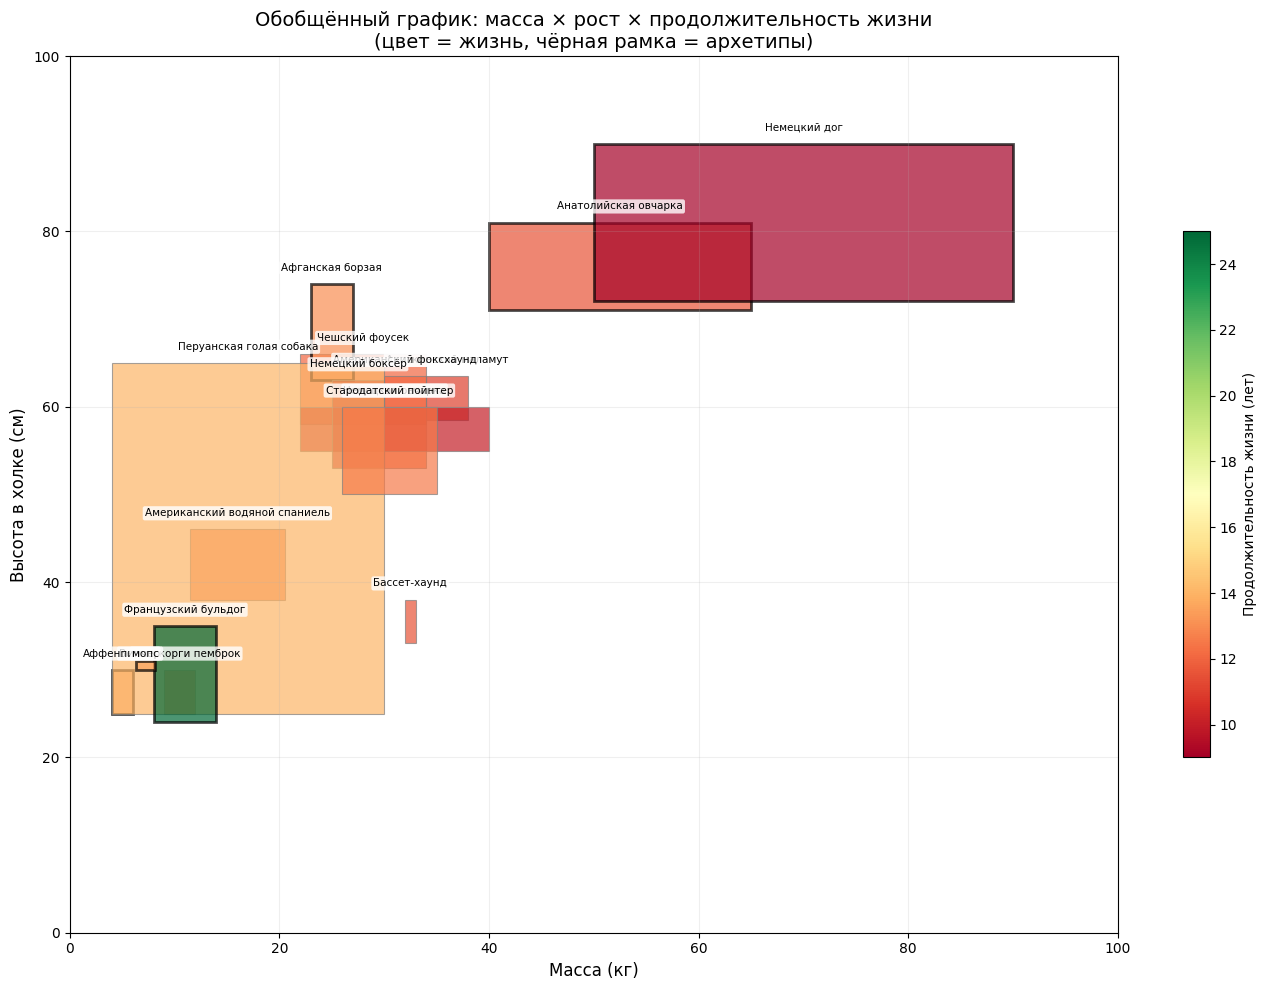

📊 Итоговая статистика:
   - Всего пород: 16
   - Диапазон жизни: 9.0 – 25.0 лет
   - Красный цвет → 9.0 лет (мало)
   - Зелёный цвет → 25.0 лет (много)
   - Чёрной рамкой выделены архетипы (6 пород)


In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

life_min = df_combined['lifeExpectancy'].min()
life_max = df_combined['lifeExpectancy'].max()
norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

# Архетипы для выделения
archetypes = {
    'Борзые': ['Афганская борзая'],
    'Мастифы': ['Немецкий дог', 'Анатолийская овчарка'],
    'Декоративные': ['мопс', 'Аффенпинчер', 'Французский бульдог']
}

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    color = cmap(norm(row['lifeExpectancy']))

    # Проверяем, принадлежит ли порода архетипу
    is_archetype = False
    for breeds in archetypes.values():
        if row['dogBreed'] in breeds:
            is_archetype = True
            break

    edgecolor = 'black' if is_archetype else 'gray'
    linewidth = 2 if is_archetype else 0.8

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=True, facecolor=color, edgecolor=edgecolor,
        alpha=0.7, linewidth=linewidth
    )
    ax.add_patch(rect)

    # Подпись
    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Обобщённый график: масса × рост × продолжительность жизни\n(цвет = жизнь, чёрная рамка = архетипы)', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"📊 Итоговая статистика:")
print(f"   - Всего пород: {len(df_combined)}")
print(f"   - Диапазон жизни: {life_min:.1f} – {life_max:.1f} лет")
print(f"   - Красный цвет → {life_min:.1f} лет (мало)")
print(f"   - Зелёный цвет → {life_max:.1f} лет (много)")
print(f"   - Чёрной рамкой выделены архетипы (6 пород)")

# 💬 Фидбек AI 3 (итоговый)

**Замечание преподавателя:** Третий график готов, объединяющий три параметра: массу, рост и продолжительность жизни.

**Что сделано:**
1. ✅ Создан отдельный ноутбук `week3_dogs_3d_combined.ipynb`
2. ✅ Рассмотрены 4 варианта кодировки продолжительности жизни
3. ✅ Выбран лучший вариант (цвет заливки)
4. ✅ Построен итоговый график с выделением архетипов

**Итоговый график показывает:**
- По оси X — массу (кг)
- По оси Y — рост (см)
- Цвет прямоугольника — продолжительность жизни (красный → мало лет, зелёный → много лет)
- Чёрная обводка — породы-архетипы

**Вывод:** Третий график наглядно демонстрирует, что более крупные породы (больше масса и рост) живут меньше (цвет ближе к красному), а мелкие породы живут дольше (цвет ближе к зелёному).